# Pothole Detection Project Documentation

## 1. Tech Stack & Libraries
This project leverages state-of-the-art computer vision tools and cloud infrastructure to build an automated pothole detection system.

*   **Core Framework**: [Ultralytics YOLOv8](https://github.com/ultralytics/ultralytics) - Used for object detection, providing a high-performance, real-time architecture.
*   **Language**: Python 3.12
*   **Environment**: Google Colab (with GPU acceleration via Tesla T4).
*   **Data Source**: [Kaggle](https://www.kaggle.com/) - Specifically the Annotated Potholes Dataset.
*   **Libraries**:
    *   `ultralytics`: Model training and inference.
    *   `opencv-python` & `PIL`: Image processing and visualization.
    *   `xml.etree.ElementTree`: Parsing XML annotations (Pascal VOC format) to YOLO format.
    *   `matplotlib`: Plotting training metrics and results.
    *   `shutil` & `pathlib`: File system management and directory restructuring.

## 2. Project Workflow Diagram
Below is the step-by-step pipeline executed in this notebook:

```mermaid
graph TD
    A[Start] --> B[Clone GitHub Repository]
    B --> C[Install Dependencies: Ultralytics]
    C --> D[Kaggle Authentication & Dataset Download]
    D --> E[Data Preprocessing]
    E --> E1[Unzip Dataset]
    E1 --> E2[Convert XML to YOLO .txt Labels]
    E2 --> E3[Create data.yaml config]
    E3 --> F[Model Training]
    F --> G[Evaluation]
    G --> G1[Visualize Training Plots]
    G1 --> G2[Run Inference on Test Images]
    G2 --> H[End]
```

## 3. Implementation Details
*   **Annotation Conversion**: The original dataset provides XML files. We convert these to YOLO format (`<class> <x_center> <y_center> <width> <height>`) normalized between 0 and 1.
*   **Training Configuration**: We use the YOLOv8 Nano (`yolov8n.pt`) model for efficiency, trained for 25 epochs at a 640px image size.

In [ ]:
!git clone https://github.com/mounishvatti/pothole_detection_yolov8.git

Cloning into 'pothole_detection_yolov8'...
remote: Enumerating objects: 61, done.
remote: Counting objects: 100% (61/61), done.
remote: Compressing objects: 100% (61/61), done.
remote: Total 61 (delta 35), reused 1 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (61/61), 20.26 MiB | 7.72 MiB/s, done.
Resolving deltas: 100% (35/35), done.


In [ ]:
%cd pothole_detection_yolov8
!pip install ultralytics

/content/pothole_detection_yolov8
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 19.8 MB/s eta 0:00:00


### Dataset Setup
To use the [Annotated Potholes Dataset](https://www.kaggle.com/datasets/chitholian/annotated-potholes-dataset), you need to upload your `kaggle.json` file or provide your Kaggle credentials. Below is a template to download it using the Kaggle API.

In [ ]:
from google.colab import files
import os

# Reset to main directory
%cd /content

# Check if kaggle.json exists, otherwise ask to upload
if not os.path.exists('/root/.kaggle/kaggle.json'):
    print('Please upload your kaggle.json file (from Kaggle -> Account -> Create New API Token)')
    uploaded = files.upload()
    !mkdir -p ~/.kaggle
    !cp kaggle.json ~/.kaggle/
    !chmod 600 ~/.kaggle/kaggle.json

# Download and extract the dataset
!kaggle datasets download -d chitholian/annotated-potholes-dataset
!unzip -o annotated-potholes-dataset.zip -d dataset

/content
Please upload your kaggle.json file (from Kaggle -> Account -> Create New API Token)


Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/chitholian/annotated-potholes-dataset
License(s): DbCL-1.0
100% 45.9M/45.9M [00:04<00:00, 11.5MB/s]

Archive:  annotated-potholes-dataset.zip
  inflating: dataset/README.md       
  inflating: dataset/annotated-images/img-1.jpg  
  inflating: dataset/annotated-images/img-1.xml  
  inflating: dataset/annotated-images/img-10.jpg  
  inflating: dataset/annotated-images/img-10.xml  
  inflating: dataset/annotated-images/img-100.jpg  
  inflating: dataset/annotated-images/img-100.xml  
  inflating: dataset/annotated-images/img-101.jpg  
  inflating: dataset/annotated-images/img-101.xml  
  inflating: dataset/annotated-images/img-102.jpg  
  inflating: dataset/annotated-images/img-102.xml  
  inflating: dataset/annotated-images/img-103.jpg  
  inflating: dataset/annotated-images/img-103.xml  
  inflating: dataset/annotated-images/img-104.jpg  
  inflating: dataset/annotated-images/img-104.xml  
  inflating: datase

In [ ]:
from ultralytics import YOLO
import os
import random
import shutil
from pathlib import Path

def ensure_split():
    dataset_path = Path('/content/dataset')
    val_images_path = dataset_path / 'val/images'
    val_labels_path = dataset_path / 'val/labels'

    # Check if validation set is already populated
    if not val_images_path.exists() or not any(val_images_path.iterdir()):
        print("Validation set not found or empty. Splitting 20% of data for validation...")

        images_path = dataset_path / 'images'
        labels_path = dataset_path / 'labels'

        # Create val directories
        val_images_path.mkdir(parents=True, exist_ok=True)
        val_labels_path.mkdir(parents=True, exist_ok=True)

        images = list(images_path.glob('*.jpg'))
        random.seed(42)
        random.shuffle(images)

        split_idx = int(len(images) * 0.2)
        val_subset = images[:split_idx]

        for img_p in val_subset:
            # Move image
            shutil.move(str(img_p), str(val_images_path / img_p.name))
            # Move corresponding label
            lbl_p = labels_path / (img_p.stem + '.txt')
            if lbl_p.exists():
                shutil.move(str(lbl_p), str(val_labels_path / lbl_p.name))
        print(f"Successfully moved {len(val_subset)} images to validation folder.")

# Main training flow
yaml_path = '/content/dataset/potholes.yaml'
if os.path.exists(yaml_path):
    ensure_split()
    # Load a pretrained YOLOv8n model
    model = YOLO('yolov8n.pt')
    # Train the model
    results = model.train(data=yaml_path, epochs=25, imgsz=640)
else:
    print(f'Error: {yaml_path} not found. Please ensure the dataset organization cell was run.')

Validation set not found or empty. Splitting 20% of data for validation...
Successfully moved 133 images to validation folder.
Ultralytics 8.4.47 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset/potholes.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1

In [ ]:
from ultralytics import YOLO

# Load a pretrained YOLOv8n model
model = YOLO('yolov8n.pt')

# Train the model
# The dataset is extracted into the 'dataset' folder.
# We point to the data.yaml file to start training.
results = model.train(data='dataset/potholes.yaml', epochs=25, imgsz=640)

Ultralytics 8.4.47 🚀 Python-3.12.13 torch-2.10.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset/potholes.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, persp

RuntimeError: Dataset 'dataset/potholes.yaml' error ❌ 'dataset/potholes.yaml' does not exist

In [ ]:
import os
import shutil
import xml.etree.ElementTree as ET
from pathlib import Path

# 1. Setup paths
base_path = Path('/content/dataset')
images_dir = base_path / 'images'
labels_dir = base_path / 'labels'

# Reset directories to ensure clean start
for d in [images_dir, labels_dir]:
    if d.exists(): shutil.rmtree(d)
    d.mkdir(parents=True, exist_ok=True)

# Ensure the source images exist
old_images_path = base_path / 'annotated-images'
if not old_images_path.exists():
    print("Re-extracting dataset to restore source files...")
    !unzip -o /content/annotated-potholes-dataset.zip -d /content/dataset

# 2. Conversion function: XML to YOLO format
def convert_xml_to_yolo(xml_file, output_path):
    try:
        tree = ET.parse(xml_file)
        root = tree.getroot()
        size = root.find('size')
        w = int(size.find('width').text)
        h = int(size.find('height').text)

        with open(output_path, 'w') as f:
            for obj in root.iter('object'):
                cls_id = 0 # 'pothole'
                xmlbox = obj.find('bndbox')
                b = (float(xmlbox.find('xmin').text), float(xmlbox.find('xmax').text),
                     float(xmlbox.find('ymin').text), float(xmlbox.find('ymax').text))
                bb = ((b[0] + b[1]) / (2.0 * w), (b[2] + b[3]) / (2.0 * h), (b[1] - b[0]) / w, (b[3] - b[2]) / h)
                f.write(f"{cls_id} {' '.join([f'{a:.6f}' for a in bb])}\n")
    except Exception as e: pass

print("Organizing dataset...")
for xml_file in old_images_path.glob('*.xml'):
    img_file = old_images_path / (xml_file.stem + '.jpg')
    if img_file.exists():
        shutil.copy(str(img_file), str(images_dir / img_file.name))
        convert_xml_to_yolo(xml_file, labels_dir / (xml_file.stem + '.txt'))

print(f"Setup complete. Total images: {len(list(images_dir.glob('*.jpg')))}")

Organizing dataset...
Setup complete. Total images: 665


### Dataset Splitting (Train/Val Split)
To properly evaluate the model, we need to move a portion of the images to a separate validation set that the model does not see during training.

In [ ]:
import random
import os
from pathlib import Path
import shutil

# Define paths
dataset_path = Path('/content/dataset')
images_path = dataset_path / 'images'
labels_path = dataset_path / 'labels'
val_path = dataset_path / 'val'

# Clean up any existing val folder for a fresh split
if val_path.exists(): shutil.rmtree(val_path)
(val_path / 'images').mkdir(parents=True)
(val_path / 'labels').mkdir(parents=True)

# Get all images
all_images = list(images_path.glob('*.jpg'))
random.seed(42)
random.shuffle(all_images)

# Split 20% for validation
split_idx = int(len(all_images) * 0.2)
val_images = all_images[:split_idx]

print(f"Moving {len(val_images)} images to validation set...")
for img_p in val_images:
    shutil.move(str(img_p), str(val_path / 'images' / img_p.name))
    label_p = labels_path / (img_p.stem + '.txt')
    if label_p.exists():
        shutil.move(str(label_p), str(val_path / 'labels' / label_p.name))

# Update YAML
yaml_content = "path: /content/dataset\ntrain: images\nval: val/images\n\nnames:\n  0: pothole"
with open(dataset_path / 'potholes.yaml', 'w') as f:
    f.write(yaml_content)

print("Dataset split complete and potholes.yaml updated.")

Moving 0 images to validation set...
Dataset split complete and potholes.yaml updated.


### Evaluate Performance on Unseen Data
Now we run the validation mode to see how the model performs on the 20% of data it was not trained on.

In [ ]:
!pip install -q ultralytics
from ultralytics import YOLO
import os

# Pointing specifically to the successful train-2 run
model_path = '/content/runs/detect/train-2/weights/best.pt'

if os.path.exists(model_path):
    print(f"Evaluating model at: {model_path}")
    model = YOLO(model_path)
    # Validate on the validation split defined in the YAML
    val_results = model.val(data='/content/dataset/potholes.yaml')

    print(f"\n--- PERFORMANCE METRICS ---")
    print(f"mAP50: {val_results.results_dict['metrics/mAP50(B)']:.4f}")
    print(f"mAP50-95: {val_results.results_dict['metrics/mAP50-95(B)']:.4f}")
else:
    print(f"Could not find model weights at {model_path}. Please check your training run.")

Evaluating model at: /content/runs/detect/train-2/weights/best.pt
Ultralytics 8.4.47 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2374.0±588.7 MB/s, size: 91.9 KB)
val: Scanning /content/dataset/val/labels.cache... 133 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 133/133 39.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 9/9 2.9it/s 3.2s
                   all        133        317      0.822      0.713      0.822      0.541
Speed: 3.2ms preprocess, 9.0ms inference, 0.0ms loss, 2.1ms postprocess per image
Results saved to /content/runs/detect/val

--- PERFORMANCE METRICS ---
mAP50: 0.8223
mAP50-95: 0.5409


### Visualize Training Results
Ultralytics automatically saves training logs and plots in the `runs` directory. Let's display the `results.png` file to see the performance trends.

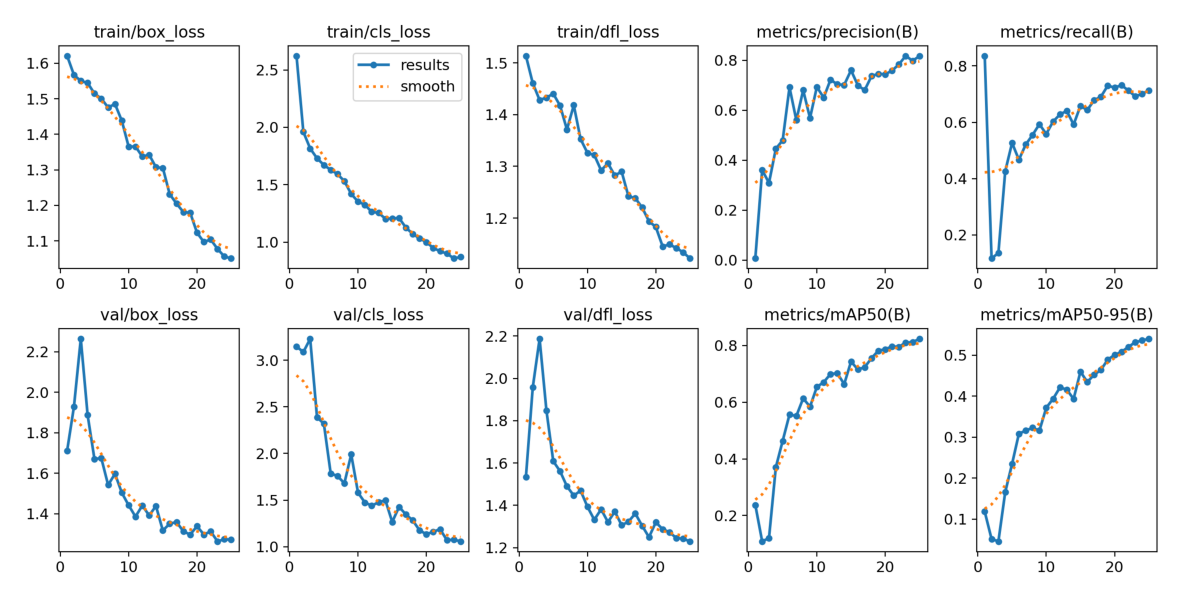

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

# Path to the results plot in the latest training run
results_path = '/content/runs/detect/train-2/results.png'

if os.path.exists(results_path):
    plt.figure(figsize=(15, 10))
    img = mpimg.imread(results_path)
    plt.imshow(img)
    plt.axis('off')
    plt.show()
else:
    print("Results image not found. Check the path.")

### Run Inference on a Sample Image
Now, we'll use the `best.pt` weights to detect potholes in an image from our dataset.


image 1/1 /content/dataset/images/img-100.jpg: 640x640 2 potholes, 7.2ms
Speed: 3.6ms preprocess, 7.2ms inference, 1.8ms postprocess per image at shape (1, 3, 640, 640)


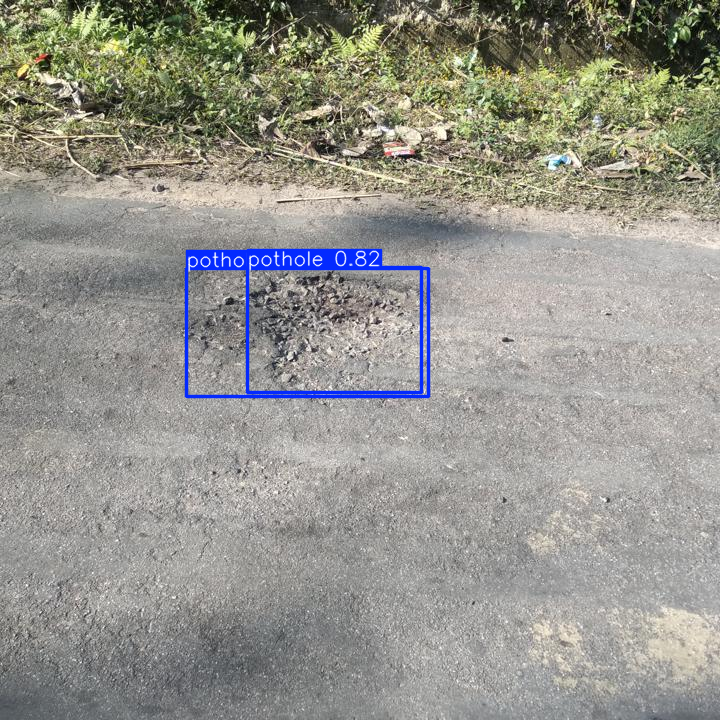

In [ ]:
from ultralytics import YOLO
import cv2
from google.colab.patches import cv2_imshow

# Load the best trained model
model_path = '/content/runs/detect/train-2/weights/best.pt'
model = YOLO(model_path)

# Select a sample image
sample_img = '/content/dataset/images/img-100.jpg'

# Run inference
results = model.predict(source=sample_img, conf=0.25)

# Plot and show the result
for r in results:
    im_array = r.plot() # plot a BGR numpy array of predictions
    cv2_imshow(im_array)

### Test Model with Your Own Image
Upload a photo to see the pothole detection model in action.

In [ ]:
%%writefile app.py
import streamlit as st
from ultralytics import YOLO
from PIL import Image
import numpy as np
import os

st.set_page_config(layout="wide", page_title="Pothole Detection AI")

st.title("🛧️ Pothole Detection System")
st.markdown("""
This application uses a fine-tuned **YOLOv8 Nano** model to identify road hazards.
Simply upload an image of a road, and the AI will highlight any potholes it detects.
""")

# Load model
model_path = '/content/runs/detect/train-2/weights/best.pt'
@st.cache_resource
def load_model():
    return YOLO(model_path)

if os.path.exists(model_path):
    model = load_model()

    uploaded_file = st.file_uploader("Choose a road image...", type=["jpg", "jpeg", "png"])

    if uploaded_file is not None:
        image = Image.open(uploaded_file)

        # Run inference
        results = model.predict(source=image, conf=0.25)

        # Process results
        for r in results:
            im_array = r.plot()  # BGR numpy array
            # Convert BGR to RGB for Streamlit
            res_image = Image.fromarray(im_array[..., ::-1])

        # Display Side by Side
        col1, col2 = st.columns(2)
        with col1:
            st.header("Original Image")
            st.image(image, use_container_width=True)
        with col2:
            st.header("AI Detection")
            st.image(res_image, use_container_width=True)
else:
    st.error("Model weights not found. Please ensure the training cell was run successfully.")

# --- Instructions to run the app in Colab ---
# !pip install streamlit localtunnel -q
# !streamlit run app.py & npx localtunnel --port 8501

Writing app.py


In [ ]:
import urllib
# Install Streamlit
!pip install streamlit -q

# Get the public IP address for localtunnel's 'Tunnel Password'
print("Your Tunnel Password is:", urllib.request.urlopen('https://ipv4.icanhazip.com').read().decode('utf8').strip())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 110.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 109.6 MB/s eta 0:00:00
Your Tunnel Password is: 35.240.180.51


In [ ]:
import time
import os

# Terminate any existing process on port 8501
!fuser -k 8501/tcp

# Run streamlit with extra flags for stability and asset loading
print("Starting Streamlit with optimized settings...")
get_ipython().system_raw('streamlit run app.py --server.port 8501 --server.enableCORS false --server.enableXsrfProtection false --server.fileWatcherType none &')

# Wait for initialization
time.sleep(8)

# Expose via localtunnel
print("Connecting to Localtunnel...")
print("If you see a module error, try refreshing the page or using a different browser.")
!npx localtunnel --port 8501

Starting Streamlit with optimized settings...
Connecting to Localtunnel...
If you see a module error, try refreshing the page or using a different browser.
⠙⠹⠸⠼your url is: https://cuddly-sides-send.loca.lt
^C


### Download Model for Local Use
Run the cell below to download your trained weights (`best.pt`). You can then use this file on your laptop with the following local command:
```bash
pip install ultralytics
yolo predict model=best.pt source=0  # 0 for webcam
```

In [ ]:
from google.colab import files
import os

model_path = '/content/runs/detect/train-2/weights/best.pt'

if os.path.exists(model_path):
    files.download(model_path)
    print("Downloading best.pt...")
else:
    print("Model weights not found. Please verify the path or if the training finished.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Local Deployment Instructions

To run this project on your laptop with your **GTX 1650**:

1. **Install Python** (3.9 or higher recommended).
2. **Install Dependencies**:
   ```bash
   pip install streamlit ultralytics
   ```
3. **Prepare the Files**:
   - Create a folder named `PotholeDetection`.
   - Move your downloaded `best.pt` into this folder.
   - Create a file named `app.py` in the same folder and paste the code from the Streamlit cell above.
   - **Important**: In your local `app.py`, change the `model_path` variable to simply `model_path = 'best.pt'`.
4. **Run the App**:
   ```bash
   streamlit run app.py
   ```